In [6]:
# Imports & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

df = pd.read_csv(Path('youtube_channels_1M_clean.csv'))

print(df.shape)
print(df.dtypes)

(1095242, 16)
channel_id                      object
channel_link                    object
channel_name                    object
subscriber_count                 int64
banner_link                     object
description                     object
keywords                        object
avatar                          object
country                         object
total_views                    float64
total_videos                   float64
join_date                       object
mean_views_last_30_videos      float64
median_views_last_30_videos    float64
std_views_last_30_videos       float64
videos_per_week                float64
dtype: object


In [3]:
# dataframe shape
print(df.shape)
df.head()

(1095242, 16)


,channel_id,channel_link,channel_name,subscriber_count,banner_link,description,keywords,avatar,country,total_views,total_videos,join_date,mean_views_last_30_videos,median_views_last_30_videos,std_views_last_30_videos,videos_per_week
0,UCUMHFa347GD8EIRaVVuxR8Q,/@TonettaClay,Tonetta Clay,781,https://yt3.googleusercontent.com/bj2C0MOj3SMi...,My name is Tonetta or Toni for short and I'm d...,NaN,https://yt3.googleusercontent.com/cUmKB4Zet1SX...,NaN,227567.0,1984.0,2015-12-08,10.866667,6.5,13.922963,1.50
1,UC28mqg7IlYWEhrZwHb72IQA,/@FoodnHappinessVeena,Food 'n' Happiness,0,NaN,"Hello viewers.\n I am Veena from Mangalore, Ka...","food n happiness, food and happiness, food, Fo...",https://yt3.googleusercontent.com/lY_u-8bLWNgA...,India,592961.0,158.0,2020-05-08,1448.066667,1510.0,869.364401,0.00
2,UCoLwWY9zQ7Jp8aDtYUszmYg,/@TimShieff,Tim Shieff,166000,https://yt3.googleusercontent.com/2KC8Lj8RF3uF...,The journey of rediscovery.\n\nhttps://rdscvr.com,"Tim, shieff, timothy, health, human, spiritual...",https://yt3.googleusercontent.com/-aNZLP23AnkX...,United Kingdom,27250763.0,372.0,2006-03-19,5456.933333,3430.0,4322.803149,0.00
3,UCAQOeJwsgBMC74-OjjcQcJA,/@JerryAndJulieMusic,Jerry & Julie Music,1090,https://yt3.googleusercontent.com/dI6Oq0iOhx-c...,Welcome to Jerry & Julie Music. We hope you w...,"jerryandjuliemusic, jerryspianobar, juliesguit...",https://yt3.googleusercontent.com/c41pe3_aA75h...,United States,339906.0,913.0,2010-03-27,75.966667,47.5,113.374448,4.00
4,UCOqwGhI1AmpWwxMYw9D_fqw,/@KichuandYugiMagizhakam,Kichu and Yugi Magizhakam,1160,https://yt3.googleusercontent.com/CXrATV8NKPRg...,Hi friends welcome to my channel...I'm Devi mo...,NaN,https://yt3.googleusercontent.com/FDA5pc1ZQ5jT...,NaN,288328.0,476.0,2023-12-21,85.700000,66.0,72.032007,1.25


In [7]:
# Descriptive Statistics
pd.set_option('display.float_format', '{:,.0f}'.format)
df.describe()


,subscriber_count,total_views,total_videos,mean_views_last_30_videos,median_views_last_30_videos,std_views_last_30_videos,videos_per_week
count,"1,095,242","1,094,490","1,094,985","1,059,085","1,059,085","1,059,085","1,059,085"
mean,"67,183","25,580,050",414,"41,739","19,376","65,037",1
std,"859,259","517,639,286","3,911","1,322,847","890,038","1,908,503",2
min,0,1,1,0,0,0,0
25%,33,"8,288",23,87,40,77,0
50%,373,"83,862",84,425,146,544,0
75%,"2,900","667,888",267,"2,588",752,"4,089",0
max,"244,000,000","178,844,248,668","1,248,360","688,938,362","671,284,026","1,069,565,293",8


In [8]:
# Missing Data
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print(missing_df[missing_df['missing_count'] > 0])

                             missing_count  missing_pct
keywords                            548039           50
country                             475183           43
banner_link                         328365           30
description                         275499           25
mean_views_last_30_videos            36157            3
median_views_last_30_videos          36157            3
std_views_last_30_videos             36157            3
videos_per_week                      36157            3
total_views                            752            0
total_videos                           257            0
channel_name                            60            0
join_date                               22            0


In [9]:
mask = df[['total_views', 'total_videos', 'channel_name', 'join_date']].isnull().any(axis=1)
print(f"Rows to be dropped: {mask.sum()}")

Rows to be dropped: 951


In [ ]:
# Handle Missing Data

# Drop irrelevant columns, these columns are URLs and free text, carry no analytical value.
df.drop(columns=['banner_link', 'description', 'avatar', 'channel_link'], inplace=True)

# Drop rows with very few missing values
df.dropna(subset=['total_views', 'total_videos', 'channel_name', 'join_date'], inplace=True)

# Impute numerical columns with median, fill with median instead of mean because the data is heavily skewed 
# the median is more representative of a typical channel than the mean which gets pulled up by mega channels.
impute_cols = ['mean_views_last_30_videos', 'median_views_last_30_videos', 
               'std_views_last_30_videos', 'videos_per_week']

for col in impute_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Confirm no missing left in key columns
print(df.isnull().sum())
print(df.shape)

In [23]:
# keywords and country: too many missing to impute
# Flag missing country as 'Unknown'
df['country'] = df['country'].fillna('Unknown')

# Flag missing keywords as empty string
df['keywords'] = df['keywords'].fillna('')

# Confirm
print(df.isnull().sum())

channel_id                     0
channel_name                   0
subscriber_count               0
keywords                       0
country                        0
total_views                    0
total_videos                   0
join_date                      0
mean_views_last_30_videos      0
median_views_last_30_videos    0
std_views_last_30_videos       0
videos_per_week                0
dtype: int64


In [24]:
df.describe()

,subscriber_count,total_views,total_videos,mean_views_last_30_videos,median_views_last_30_videos,std_views_last_30_videos,videos_per_week
count,"1,094,291","1,094,291","1,094,291","1,094,291","1,094,291","1,094,291","1,094,291"
mean,"67,183","25,581,588",414,"39,780","18,580","61,785",1
std,"858,769","517,678,339","3,912","1,277,863","873,083","1,811,498",2
min,0,1,1,0,0,0,0
25%,34,"8,290",23,93,42,83,0
50%,374,"83,870",84,426,146,545,0
75%,"2,910","667,946",267,"2,404",699,"3,786",0
max,"244,000,000","178,844,248,668","1,248,360","688,938,362","671,284,026","1,069,565,293",8


In [14]:
# Top Countries
print(df['country'].value_counts().head(10))

country
United States     239797
India             117643
United Kingdom     44092
Canada             26306
Pakistan           19949
Australia          14098
Philippines        13400
Germany             9817
Indonesia           9549
Brazil              6470
Name: count, dtype: int64


subscriber_count: 192,944 outliers (17.63%)
total_views: 194,012 outliers (17.73%)
total_videos: 123,804 outliers (11.31%)


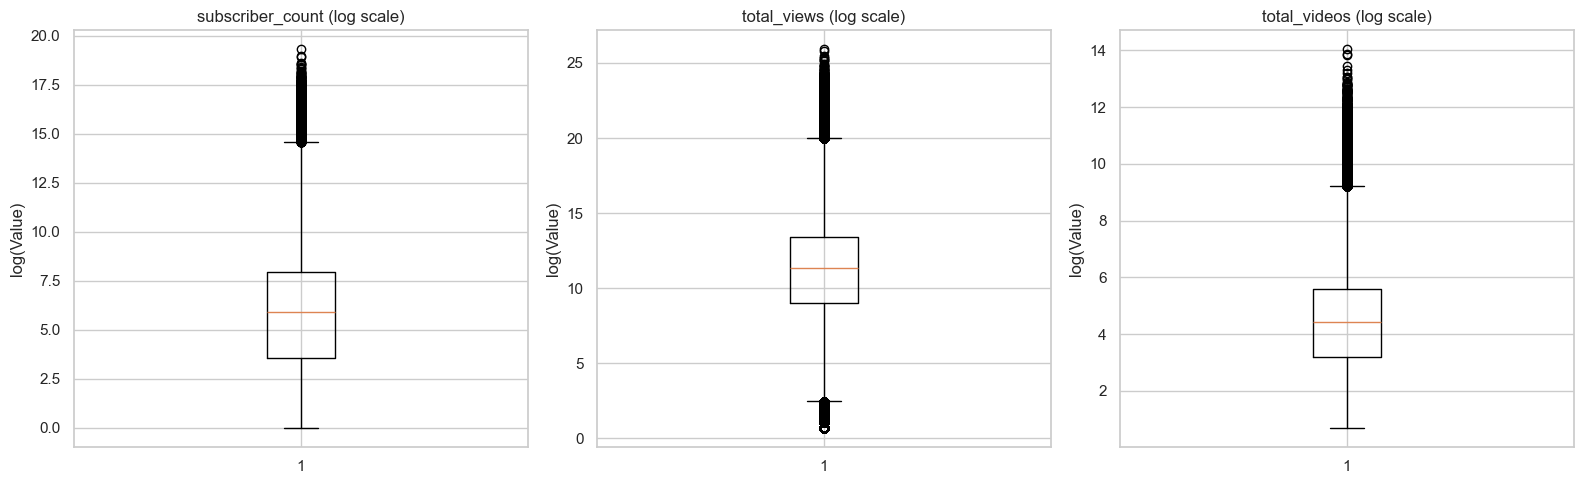

In [26]:
# Outliers: IQR Detection + Log Boxplot

# IQR method to count outliers
def count_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    pct = (outliers / len(df) * 100).round(2)
    print(f"{col}: {outliers:,} outliers ({pct}%)")

cols = ['subscriber_count', 'total_views', 'total_videos']
for col in cols:
    count_outliers(col)

# Visualize on log scale — much easier to read
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(cols):
    axes[i].boxplot(np.log1p(df[col]), vert=True)
    axes[i].set_title(f'{col} (log scale)')
    axes[i].set_ylabel('log(Value)')

plt.tight_layout()
plt.show()

In [16]:
# Join Date range
print(df['join_date'].min())
print(df['join_date'].max())

2005-05-02
2024-03-09


In [28]:
# Top 20 Channels by Subscriber Count
df[['channel_name', 'country', 'subscriber_count', 'total_views', 'total_videos']] \
    .sort_values('subscriber_count', ascending=False) \
    .head(20) \
    .reset_index(drop=True)

,channel_name,country,subscriber_count,total_views,total_videos
0,MrBeast,United States,244000000,"44,572,869,225",780
1,Cocomelon - Nursery Rhymes,United States,172000000,"178,844,248,668","1,103"
2,SET India,India,169000000,"160,051,700,577","131,706"
3,✿ Kids Diana Show,United States,120000000,"101,036,876,957","1,171"
4,Vlad and Niki,United States,113000000,"86,954,469,193",672
5,Like Nastya,United States,113000000,"98,414,739,745",871
6,PewDiePie,Japan,111000000,"29,250,177,902","4,755"
7,WWE,Unknown,100000000,"82,295,464,964","74,434"
8,BLACKPINK,South Korea,93100000,"32,138,872,208",592
9,Sony SAB,India,90000000,"111,502,005,120","81,164"


In [35]:
# Feature Engineering

# 1. Views per subscriber (efficiency metric)
df['views_per_subscriber'] = df['total_views'] / (df['subscriber_count'] + 1)

# 2. Videos per subscriber (productivity metric)
df['videos_per_subscriber'] = df['total_videos'] / (df['subscriber_count'] + 1)

# 3. Account age in years
df['join_date'] = pd.to_datetime(df['join_date'])
df['account_age_years'] = (pd.Timestamp('2024-01-01') - df['join_date']).dt.days / 365

# 4. Views per video (content quality proxy)
df['views_per_video'] = df['total_views'] / (df['total_videos'] + 1)

# Verify
print(df[['channel_name', 'subscriber_count', 'views_per_subscriber', 
          'account_age_years', 'views_per_video']].head(5))

                channel_name  subscriber_count  views_per_subscriber  \
0               Tonetta Clay               781                   291   
1         Food 'n' Happiness                 0               592,961   
2                 Tim Shieff            166000                   164   
3        Jerry & Julie Music              1090                   312   
4  Kichu and Yugi Magizhakam              1160                   248   

   account_age_years  views_per_video  
0                  8              115  
1                  4            3,729  
2                 18           73,058  
3                 14              372  
4                  0              604  


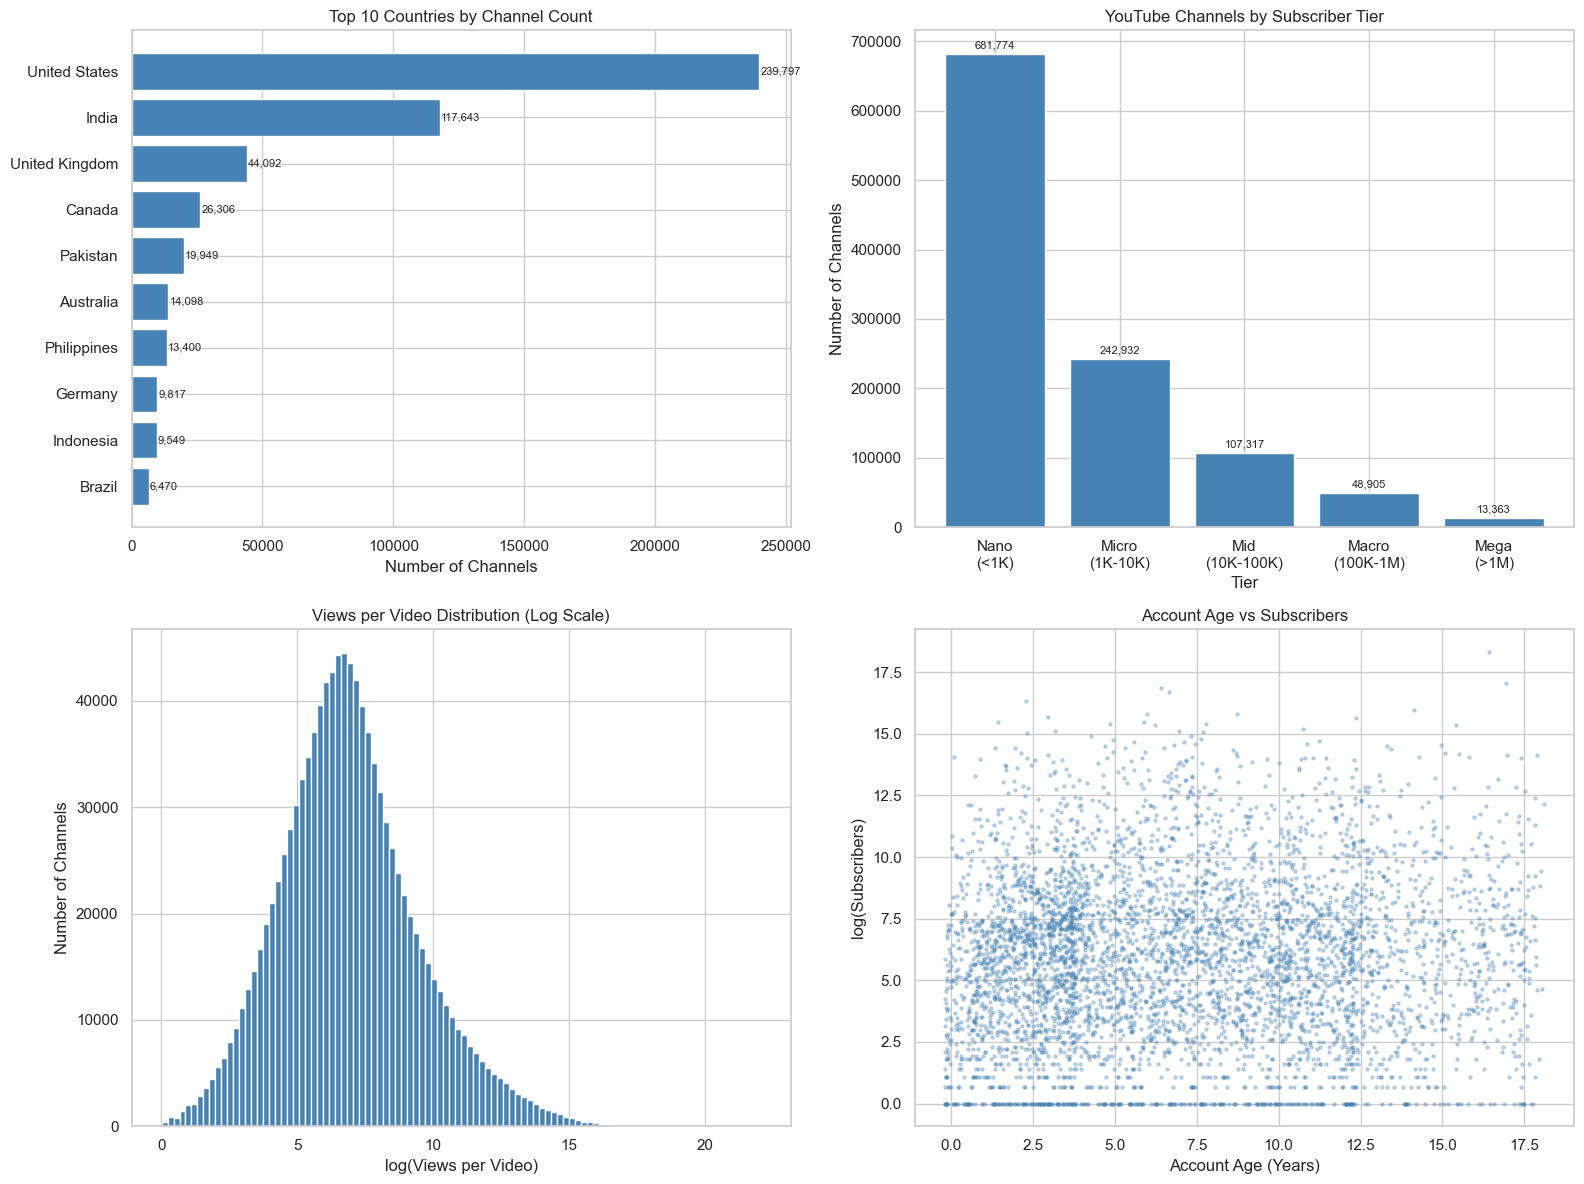

In [40]:
# Data Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 10 countries by channel count
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)
bars_country = axes[0, 0].barh(top_countries.index[::-1], top_countries.values[::-1], color='steelblue')
for bar, count in zip(bars_country, top_countries.values[::-1]):
    axes[0, 0].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                    f'{count:,}', va='center', fontsize=8)
axes[0, 0].set_title('Top 10 Countries by Channel Count')
axes[0, 0].set_xlabel('Number of Channels')

# 2. Channel count by subscriber tier (binning chart)
tier_counts = df['subscriber_tier'].value_counts().sort_index()
bars = axes[0, 1].bar(tier_counts.index, tier_counts.values, color='steelblue', edgecolor='white')
for bar, count in zip(bars, tier_counts.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                    f'{count:,}', ha='center', va='bottom', fontsize=8)
axes[0, 1].set_title('YouTube Channels by Subscriber Tier')
axes[0, 1].set_xlabel('Tier')
axes[0, 1].set_ylabel('Number of Channels')

# 3. Views per video distribution (log scale)
axes[1, 0].hist(np.log1p(df['views_per_video']), bins=100, color='steelblue', edgecolor='white')
axes[1, 0].set_title('Views per Video Distribution (Log Scale)')
axes[1, 0].set_xlabel('log(Views per Video)')
axes[1, 0].set_ylabel('Number of Channels')

# 4. Account age vs log subscribers (scatter)
sample = df.sample(5000, random_state=42)
axes[1, 1].scatter(sample['account_age_years'], sample['log_subscribers'],
                   alpha=0.3, s=5, color='steelblue')
axes[1, 1].set_title('Account Age vs Subscribers')
axes[1, 1].set_xlabel('Account Age (Years)')
axes[1, 1].set_ylabel('log(Subscribers)')

plt.tight_layout()
plt.show()

In [38]:
# Log to actual views per video conversion table
log_values = [0, 2, 4, 6, 8, 10, 12, 14]
print(f"{'Log value':<12} {'Actual views per video':>25}")
print("-" * 38)
for l in log_values:
    actual = int(np.expm1(l))
    print(f"{l:<12} {actual:>25,}")

Log value       Actual views per video
--------------------------------------
0                                    0
2                                    6
4                                   53
6                                  402
8                                2,979
10                              22,025
12                             162,753
14                           1,202,603
